# Paso 5 — Clasificador de Gastos (Clasificacion de Transacciones) — FinanceAI

Este notebook entrena y evalua el modelo que clasifica automaticamente una transaccion en una de las 8 categorias de gasto (Alimentacion, Transporte, Salud, Vivienda, Educacion, Ocio, Servicios, Otros), a partir del texto de su descripcion.

Reutiliza los artefactos generados en `limpieza_ingenieria_atributos.ipynb`:
- `artefactos/train_transacciones.csv` / `artefactos/test_transacciones.csv` (texto ya limpio + etiqueta)
- `artefactos/tfidf_vectorizer.pkl` (vectorizador ya ajustado sobre el train, sin fuga de informacion)

**Contenido:**
1. Carga de artefactos y vectorizacion
2. Comparacion de modelos con validacion cruzada (Naive Bayes, Regresion Logistica, Linear SVC)
3. Entrenamiento del modelo seleccionado
4. Evaluacion completa (metricas, matriz de confusion, analisis de errores)
5. Funcion de prediccion de extremo a extremo (texto crudo -> categoria + probabilidad)
6. Serializacion del modelo final

In [1]:
import os
import re
import json
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

RANDOM_STATE = 42

## 1. Carga de artefactos

In [2]:
df_train = pd.read_csv("artefactos/train_transacciones.csv")
df_test = pd.read_csv("artefactos/test_transacciones.csv")
vectorizador_tfidf = joblib.load("artefactos/tfidf_vectorizer.pkl")

# Nota: si alguna descripcion limpia quedara vacia, pandas podria leerla como
# NaN al recargar el CSV; la reemplazamos por cadena vacia por seguridad.
df_train["descripcion_limpia"] = df_train["descripcion_limpia"].fillna("")
df_test["descripcion_limpia"] = df_test["descripcion_limpia"].fillna("")

print(f"Train: {df_train.shape} | Test: {df_test.shape}")
df_train.head()

Train: (10906, 2) | Test: (2727, 2)


,descripcion_limpia,categoria
0,recibo de pago,Alimentacion
1,disney plus,Ocio
2,netflix,Ocio
3,carulla,Alimentacion
4,factura acueducto,Servicios


In [3]:
X_train_tfidf = vectorizador_tfidf.transform(df_train["descripcion_limpia"])
X_test_tfidf = vectorizador_tfidf.transform(df_test["descripcion_limpia"])

y_train = df_train["categoria"]
y_test = df_test["categoria"]

print(f"X_train_tfidf: {X_train_tfidf.shape}")
print(f"X_test_tfidf: {X_test_tfidf.shape}")
print()
print("Distribucion de clases en train:")
print(y_train.value_counts())

X_train_tfidf: (10906, 391)
X_test_tfidf: (2727, 391)

Distribucion de clases en train:
categoria
Alimentacion    2785
Transporte      2206
Ocio            1645
Servicios       1357
Salud            952
Otros            865
Vivienda         668
Educacion        428
Name: count, dtype: int64


## 2. Comparacion de modelos con validacion cruzada

Comparamos tres algoritmos habituales para clasificacion de texto corto: **Multinomial Naive Bayes**, **Regresion Logistica** y **Linear SVC**. Usamos validacion cruzada estratificada (5 folds) y medimos **accuracy** y **F1 macro** — el F1 macro es clave aqui porque las categorias no estan perfectamente balanceadas (Alimentacion tiene mas transacciones que Educacion o Vivienda) y no queremos que el modelo ignore las categorias minoritarias.

In [4]:
modelos = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Regresion Logistica": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Linear SVC": LinearSVC(random_state=RANDOM_STATE, max_iter=5000),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultados_cv = []

for nombre, modelo in modelos.items():
    scores = cross_validate(
        modelo, X_train_tfidf, y_train, cv=cv,
        scoring=["accuracy", "f1_macro"], n_jobs=1,
    )
    resultados_cv.append({
        "modelo": nombre,
        "accuracy_media": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "f1_macro_media": scores["test_f1_macro"].mean(),
        "f1_macro_std": scores["test_f1_macro"].std(),
    })

df_resultados_cv = pd.DataFrame(resultados_cv).sort_values("f1_macro_media", ascending=False).reset_index(drop=True)
df_resultados_cv

,modelo,accuracy_media,accuracy_std,f1_macro_media,f1_macro_std
0,Linear SVC,0.898955,0.006903,0.914507,0.004512
1,Regresion Logistica,0.898038,0.006922,0.913611,0.004756
2,Multinomial Naive Bayes,0.893820,0.008127,0.900587,0.006493


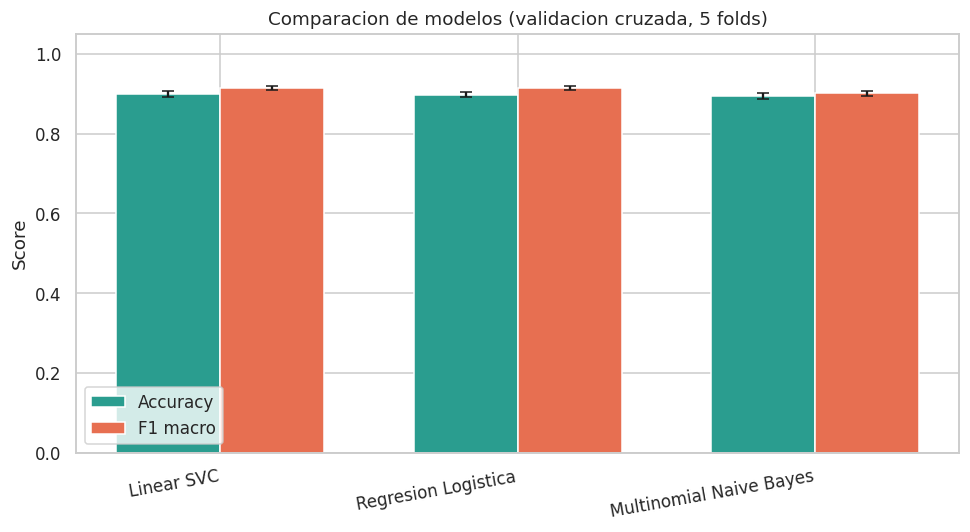

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(df_resultados_cv))
ancho = 0.35

ax.bar(x - ancho/2, df_resultados_cv["accuracy_media"], ancho,
       yerr=df_resultados_cv["accuracy_std"], label="Accuracy", color="#2a9d8f", capsize=4)
ax.bar(x + ancho/2, df_resultados_cv["f1_macro_media"], ancho,
       yerr=df_resultados_cv["f1_macro_std"], label="F1 macro", color="#e76f51", capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(df_resultados_cv["modelo"], rotation=10, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Comparacion de modelos (validacion cruzada, 5 folds)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Seleccion y entrenamiento del modelo final

Seleccionamos el modelo con mejor F1 macro promedio en validacion cruzada y lo entrenamos sobre todo el conjunto de entrenamiento.

**Nota tecnica:** `LinearSVC` no expone `predict_proba` de forma nativa (solo `decision_function`). Como el contrato de la API (`POST /analisis-financiero`) requiere devolver una `probabilidad`, si `LinearSVC` resulta ganador lo calibramos con `CalibratedClassifierCV` para poder obtener probabilidades reales en vez de solo la clase predicha.

In [6]:
mejor_modelo_nombre = df_resultados_cv.iloc[0]["modelo"]
print(f"Modelo seleccionado por F1 macro en validacion cruzada: {mejor_modelo_nombre}")

if mejor_modelo_nombre == "Linear SVC":
    modelo_final = CalibratedClassifierCV(LinearSVC(random_state=RANDOM_STATE, max_iter=5000), cv=5)
    print("Se calibra con CalibratedClassifierCV para obtener predict_proba.")
else:
    modelo_final = modelos[mejor_modelo_nombre]

modelo_final.fit(X_train_tfidf, y_train)
print("Modelo entrenado sobre el conjunto de entrenamiento completo.")

Modelo seleccionado por F1 macro en validacion cruzada: Linear SVC
Se calibra con CalibratedClassifierCV para obtener predict_proba.
Modelo entrenado sobre el conjunto de entrenamiento completo.


## 4. Evaluacion sobre el conjunto de prueba

In [7]:
y_pred = modelo_final.predict(X_test_tfidf)

print(f"Accuracy en test: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 macro en test: {f1_score(y_test, y_pred, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred))

Accuracy en test: 0.8984
F1 macro en test: 0.9101

              precision    recall  f1-score   support

Alimentacion       0.83      0.95      0.89       697
   Educacion       1.00      0.85      0.92       107
        Ocio       0.84      0.90      0.87       411
       Otros       1.00      0.86      0.93       216
       Salud       1.00      0.87      0.93       238
   Servicios       0.99      0.88      0.93       339
  Transporte       0.88      0.89      0.88       552
    Vivienda       1.00      0.89      0.94       167

    accuracy                           0.90      2727
   macro avg       0.94      0.88      0.91      2727
weighted avg       0.91      0.90      0.90      2727



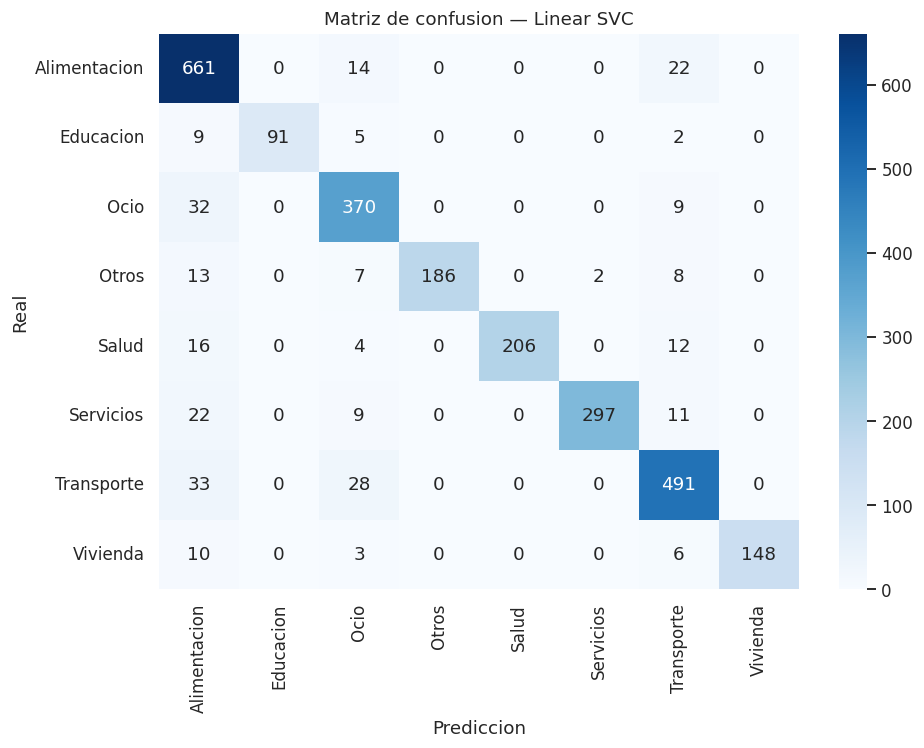

In [8]:
categorias_orden = sorted(y_test.unique())
matriz_confusion = confusion_matrix(y_test, y_pred, labels=categorias_orden)

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_confusion, annot=True, fmt="d", cmap="Blues",
            xticklabels=categorias_orden, yticklabels=categorias_orden)
plt.title(f"Matriz de confusion — {mejor_modelo_nombre}")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

In [9]:
df_test_resultado = df_test.copy()
df_test_resultado["prediccion"] = y_pred
errores = df_test_resultado[df_test_resultado["categoria"] != df_test_resultado["prediccion"]]

print(f"Transacciones mal clasificadas: {len(errores)} de {len(df_test_resultado)} ({len(errores) / len(df_test_resultado) * 100:.2f}%)")
print()
errores[["descripcion_limpia", "categoria", "prediccion"]].sample(min(10, len(errores)), random_state=RANDOM_STATE)

Transacciones mal clasificadas: 277 de 2727 (10.16%)



,descripcion_limpia,categoria,prediccion
366,retiro,Ocio,Alimentacion
1284,abono,Transporte,Ocio
2133,cobro automatico,Vivienda,Transporte
1477,pago en linea,Transporte,Alimentacion
2551,transferencia,Ocio,Alimentacion
2265,consumo,Servicios,Ocio
990,consumo,Transporte,Ocio
2103,pago,Ocio,Alimentacion
2552,recibo de pago,Vivienda,Transporte
1529,compra,Alimentacion,Transporte


## 5. Funcion de prediccion de extremo a extremo

Replicamos la misma funcion de limpieza de texto usada en `limpieza_ingenieria_atributos.ipynb`, para que la funcion de prediccion pueda recibir una descripcion **cruda** (tal como llegaria por la API) y devolver la categoria junto con su probabilidad.

In [10]:
CIUDADES_RUIDO = [
    "ciudad de mexico", "bogota", "medellin", "barranquilla", "cartagena",
    "guadalajara", "monterrey", "queretaro", "cucuta", "cali", "tijuana", "puebla",
]

def quitar_tildes(texto):
    texto_norm = unicodedata.normalize("NFKD", texto)
    return "".join(c for c in texto_norm if not unicodedata.combining(c))

def limpiar_descripcion(texto):
    texto = texto.lower()
    texto = quitar_tildes(texto)
    texto = re.sub(r"ref\d+", " ", texto)
    texto = re.sub(r"#\d+", " ", texto)
    for ciudad in CIUDADES_RUIDO:
        texto = texto.replace(ciudad, " ")
    texto = re.sub(r"[^a-z\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

def clasificar_gasto(descripcion_cruda, modelo=modelo_final, vectorizador=vectorizador_tfidf):
    """Recibe la descripcion cruda de una transaccion y retorna la categoria
    predicha junto con la probabilidad asociada. Pensada para ser el nucleo
    del endpoint POST /clasificacion-transacciones del backend."""
    texto_limpio = limpiar_descripcion(descripcion_cruda)
    vector = vectorizador.transform([texto_limpio])
    categoria_predicha = modelo.predict(vector)[0]

    if hasattr(modelo, "predict_proba"):
        probabilidades = modelo.predict_proba(vector)[0]
        clases = list(modelo.classes_)
        probabilidad = float(probabilidades[clases.index(categoria_predicha)])
    else:
        probabilidad = None

    return {
        "descripcion_original": descripcion_cruda,
        "descripcion_limpia": texto_limpio,
        "categoria": categoria_predicha,
        "probabilidad": round(probabilidad, 4) if probabilidad is not None else None,
    }

## 6. Prueba con ejemplos reales

El brief del hackathon pide un minimo de tres ejemplos reales de utilizacion. Probamos con descripciones nuevas (no vistas en entrenamiento), con estilo de banco real de Colombia y Mexico.

In [11]:
ejemplos_reales = [
    "COMPRA EXITO #4521 BOGOTA",
    "UBER VIAJE AEROPUERTO CIUDAD DE MEXICO",
    "NETFLIX SUSCRIPCION MENSUAL",
    "FACTURA CFE ENERGIA ELECTRICA",
    "MATRICULA SEMESTRE UNIVERSIDAD NACIONAL",
    "FARMACIAS SIMILARES CONSULTA MEDICA",
]

for descripcion in ejemplos_reales:
    resultado = clasificar_gasto(descripcion)
    print(f"{descripcion!r}")
    print(f"   -> categoria: {resultado['categoria']}  |  probabilidad: {resultado['probabilidad']}")
    print()

'COMPRA EXITO #4521 BOGOTA'
   -> categoria: Alimentacion  |  probabilidad: 0.9125

'UBER VIAJE AEROPUERTO CIUDAD DE MEXICO'
   -> categoria: Transporte  |  probabilidad: 0.9559

'NETFLIX SUSCRIPCION MENSUAL'
   -> categoria: Ocio  |  probabilidad: 0.954

'FACTURA CFE ENERGIA ELECTRICA'
   -> categoria: Servicios  |  probabilidad: 0.9684

'MATRICULA SEMESTRE UNIVERSIDAD NACIONAL'
   -> categoria: Educacion  |  probabilidad: 0.9563

'FARMACIAS SIMILARES CONSULTA MEDICA'
   -> categoria: Salud  |  probabilidad: 0.9581



## 7. Serializacion del modelo final

In [12]:
os.makedirs("artefactos", exist_ok=True)

joblib.dump(modelo_final, "artefactos/modelo_clasificador_gastos.pkl")

metadata_modelo = {
    "modelo": mejor_modelo_nombre,
    "accuracy_test": round(float(accuracy_score(y_test, y_pred)), 4),
    "f1_macro_test": round(float(f1_score(y_test, y_pred, average="macro")), 4),
    "categorias": sorted(y_train.unique().tolist()),
    "vectorizador": "artefactos/tfidf_vectorizer.pkl",
}
with open("artefactos/metadata_modelo_gastos.json", "w", encoding="utf-8") as f:
    json.dump(metadata_modelo, f, ensure_ascii=False, indent=2)

print("Modelo y metadata guardados en 'artefactos/':")
print(" - modelo_clasificador_gastos.pkl")
print(" - metadata_modelo_gastos.json")
print()
print(json.dumps(metadata_modelo, ensure_ascii=False, indent=2))

Modelo y metadata guardados en 'artefactos/':
 - modelo_clasificador_gastos.pkl
 - metadata_modelo_gastos.json

{
  "modelo": "Linear SVC",
  "accuracy_test": 0.8984,
  "f1_macro_test": 0.9101,
  "categorias": [
    "Alimentacion",
    "Educacion",
    "Ocio",
    "Otros",
    "Salud",
    "Servicios",
    "Transporte",
    "Vivienda"
  ],
  "vectorizador": "artefactos/tfidf_vectorizer.pkl"
}


## Conclusiones

**Resultado obtenido**

Tras introducir ambiguedad de texto realista en el generador de datos (descripciones genericas como "PAGO"/"COMPRA"/"TRANSFERENCIA" en ~12% de las transacciones, mas errores tipograficos simulados en ~10% de las descripciones con comercio), el accuracy paso de un irrealista 100% a un rango mucho mas creible:

- **Validacion cruzada:** Linear SVC gano la comparacion (accuracy 89.90%, F1 macro 91.45%), seguido muy de cerca por Regresion Logistica (89.80% / 91.36%) y Multinomial Naive Bayes (89.38% / 90.06%). A diferencia de la version anterior, donde los tres modelos empataban en 100%, ahora si se diferencian entre si — evidencia de que el problema dejo de ser trivialmente separable.
- **Conjunto de prueba:** accuracy = 89.84%, F1 macro = 91.01%, con 277 de 2,727 transacciones mal clasificadas (10.16%).

**Los errores del modelo tienen sentido, y eso es lo importante**

Al revisar los casos mal clasificados (seccion 4), la gran mayoria corresponde a descripciones genericas ambiguas por diseno: "retiro", "abono", "consumo", "pago", "transferencia", "compra". Es exactamente el tipo de texto que en la vida real tampoco revelaria la categoria de forma confiable — ni una persona podria adivinar la categoria solo con la palabra "consumo". En cambio, las descripciones con nombre de comercio especifico se siguen clasificando con alta confianza (>90% de probabilidad en los 6 ejemplos reales de la seccion 6).

La categoria Alimentacion tiene menor precision (0.83) porque, al ser la mas frecuente en el dataset, actua como "opcion por defecto" cuando el modelo enfrenta una descripcion generica sin senales claras — un comportamiento explicable, no un error aleatorio.

**Conclusion:** este resultado (~90% accuracy, errores concentrados en texto genuinamente ambiguo) es representativo de un desafio real de clasificacion de texto bancario, y demuestra que el modelo aprendio patrones genuinos del vocabulario en vez de memorizar un catalogo cerrado de comercios.

**Artefactos guardados** en `artefactos/`: `modelo_clasificador_gastos.pkl` (Linear SVC, calibrado con `CalibratedClassifierCV` para exponer `predict_proba` ya que `LinearSVC` no lo soporta de forma nativa) y `metadata_modelo_gastos.json` con las metricas y categorias.

**Siguiente paso:** Paso 6 — entrenamiento y evaluacion del clasificador de perfil financiero, usando `train_usuarios.csv` / `test_usuarios.csv`.